In [1]:
import pandas as pd
from datasets import load_dataset
import sys
sys.path.append("..")

from tqdm import tqdm
tqdm.pandas()

from python_editor.data_processing import get_pylint_text, get_pylint_score

We use the test set initially because it is smaller to just discover patterns

In [ ]:
ds = load_dataset("tomekkorbak/python-github-code", split="test")
ds.set_format("pandas")

df = ds[:]
df.drop(columns=["language", "score"], axis=1, inplace=True)
df = df.rename(columns={"size": "NUM_CHARS"})

df["pylint_text"] = df.progress_apply(get_pylint_text, axis=1)
df["pylint_score"] = df.progress_apply(get_pylint_score, axis=1)
df = df[df["pylint_score"] != -1]

'\nds = load_dataset("tomekkorbak/python-github-code", split="test")\nds.set_format("pandas")\n\ndf = ds[:]\ndf.drop(columns=["language", "score"], axis=1, inplace=True)\n\ndf["pylint_text"] = df.progress_apply(get_pylint_text, axis=1)\ndf["pylint_score"] = df.progress_apply(get_pylint_score, axis=1)\ndf = df[df["pylint_score"] != -1]\n\ndf.to_csv("../data/exploration.csv", index=False)\n'

There are no nulls and dtypes are valid

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5717 entries, 0 to 5716
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   text          5717 non-null   object 
 1   repo_name     5717 non-null   object 
 2   path          5717 non-null   object 
 3   license       5717 non-null   object 
 4   NUM_CHARS     5717 non-null   int64  
 5   pylint_text   5717 non-null   object 
 6   pylint_score  5717 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 312.8+ KB


Examining licenses shows that most data are safe to be used for training. We will avoid risky/conditional licenses

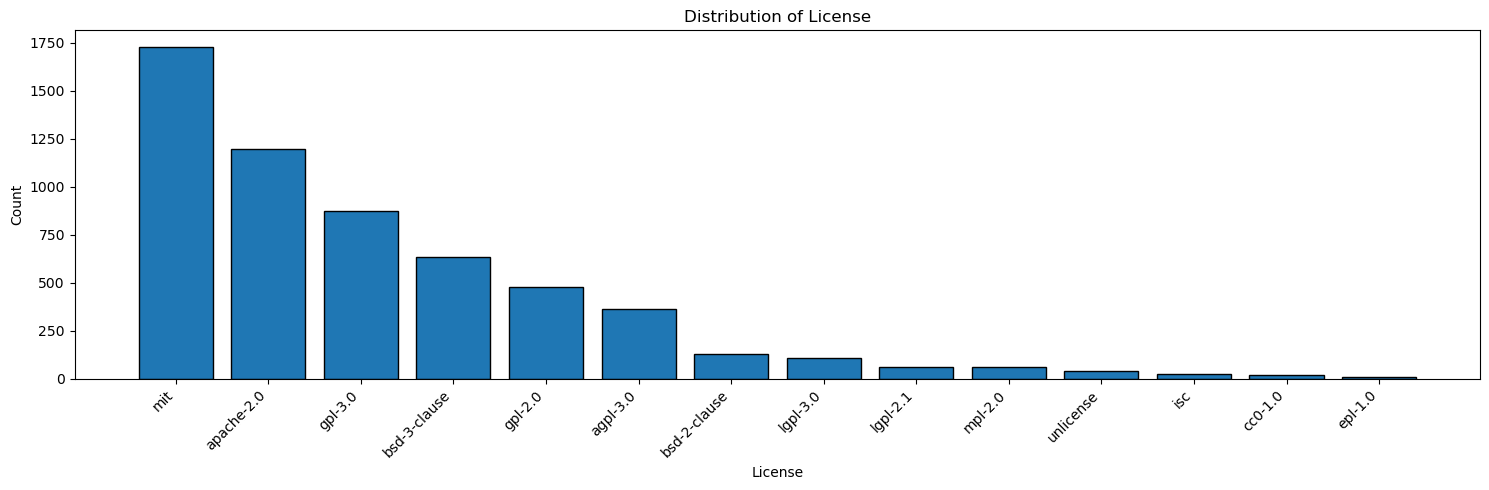

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(15, 5))
counts = df["license"].value_counts()

plt.bar(counts.index, counts.values, edgecolor="black")

plt.title("Distribution of License")
plt.xlabel("License")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [8]:
SAFE_LICENSES = [
    "mit",
    "apache-2.0",
    "bsd-3-clause",
    "bsd-2-clause",
    "isc",
    "cc0-1.0"
]

df = df[df["license"].isin(SAFE_LICENSES)]
print(f"{len(df)} examples remained")

3726 examples remained


Distribution of size is right-skewed

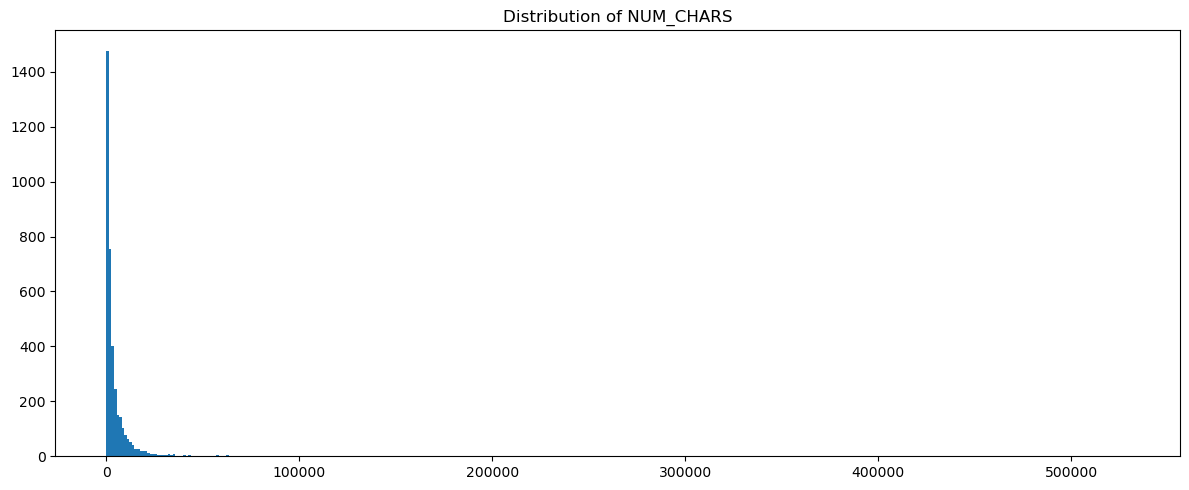

In [12]:
fig = plt.figure(figsize=(12,5))
plt.hist(df["NUM_CHARS"], bins=400)
plt.title("Distribution of NUM_CHARS")

plt.tight_layout()
plt.show()

Most example's NUM_CHARS is below 40k so we set this as a limit

In [13]:
df["NUM_CHARS"].quantile(0.99)

np.float64(39544.75)

In [14]:
df = df[df["NUM_CHARS"] <= 40000]
print(f"{len(df)} examples remained")

3689 examples remained


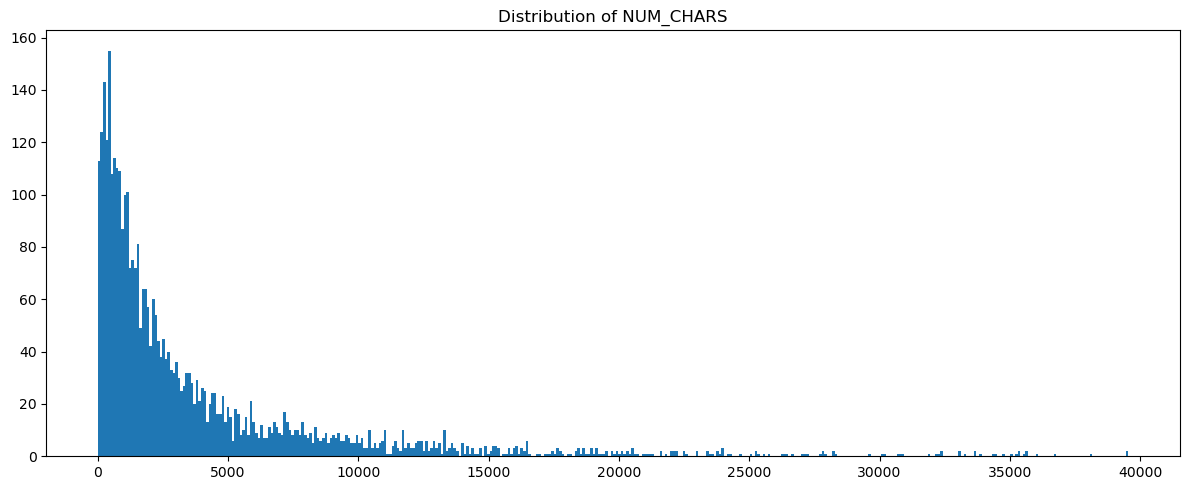

In [15]:
fig = plt.figure(figsize=(12,5))
plt.hist(df["NUM_CHARS"], bins=400)
plt.title("Distribution of NUM_CHARS")

plt.tight_layout()
plt.show()

We see that on average larger the NUM_CHARS larger the score

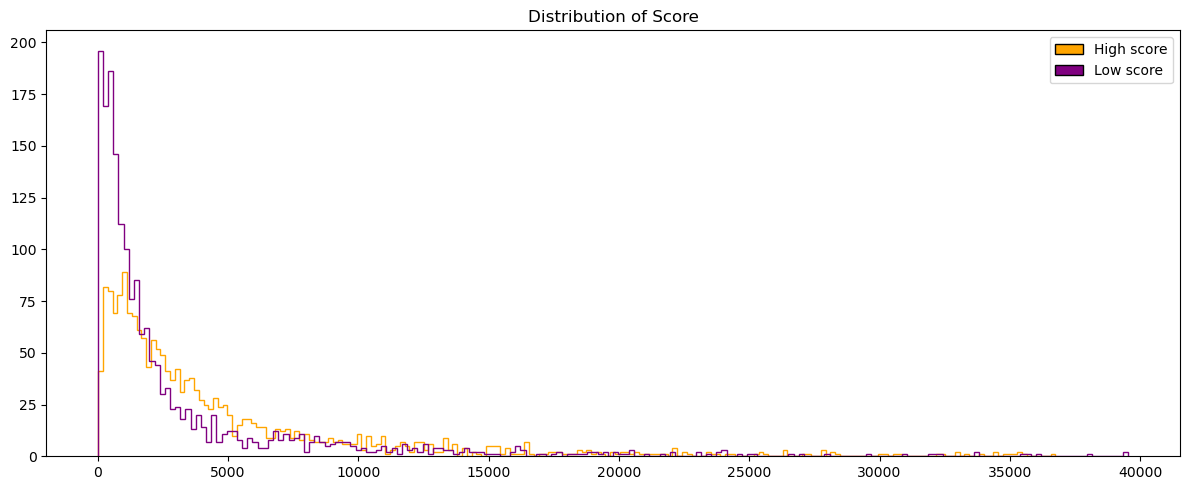

In [16]:
high_score = df["pylint_score"] > df["pylint_score"].median()

fig = plt.figure(figsize=(12,5))
plt.hist(df[high_score]["NUM_CHARS"], bins=200, histtype="step", color="orange")
plt.hist(df[~high_score]["NUM_CHARS"], bins=200, histtype="step", color="purple")

plt.title("Distribution of Score")
handles = [Rectangle((0, 0), 1, 1, color=c, ec="k") for c in ["orange", "purple"]]
labels = ["High score", "Low score"]
plt.legend(handles, labels)

plt.tight_layout()
plt.show()

We save the dataset to load it quickly later

In [17]:
df.to_csv("../data/exploration.csv", index=False)